# §4.1.1 Comparison of results: Spatial Resolution

This notebook contains a comparison of modeled county-level 5 PM EV charging loads in California against Broga et al. (2024), who modeled medium- and heavy-duty EV charging for the same counties under a separate modeling framework.

The validation uses a special single-scenario run (`validate` environment) that matches Broga et al.'s adoption assumptions as closely as possible.

**Generates:** appendix Figure A.13 (county-level 5 PM load, LAUREL vs Broga et al.).

## Load modules

In [1]:
import pandas as pd
import seaborn as sns

from laurel.scenario_builders.sense import SenseScenarioReader

## Set global variables

In [2]:
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")

## Load data

In [3]:
%reload_ext kedro.ipython
%reload_kedro --env=scenario_builders/sense_manage --params=data_dir=/scratch/users/passow/laurel/data

[06/11/26 09:27:19] INFO     Using                                                                  ]8;id=440030;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=60721;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py#270\270]8;;\
                             '/home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/fr                
                             amework/project/rich_logging.yml' as logging configuration.                           

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=456610;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=194992;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#63\63]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=34148;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=596709;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#65\65]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=726674;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=957683;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:27:21] INFO     Kedro project LAUREL                                                   ]8;id=915325;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=389201;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

...

[06/11/26 09:27:22] INFO     Registered line magic 'run_viz'                                        ]8;id=825006;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=938241;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=570009;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=199052;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:27:23] INFO     Kedro project LAUREL                                                   ]8;id=696542;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=725354;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=272461;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=158102;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=846304;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=767009;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

In [4]:
valid_reader = SenseScenarioReader(dirs=["validate"])

quant_parts_ctys = catalog.load("county.report_by_region_quantiles_scenario")
quants_ctys = valid_reader.read_partitions(quant_parts_ctys)

summs_ctys_parts = catalog.load("county.report_by_region_summaries_scenario")
summs_ctys = valid_reader.read_partitions(summs_ctys_parts)

                    INFO     Loading data from county.report_by_region_quantiles_scenario      ]8;id=27799;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=208628;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (PartitionedDataset)...                                                               

                    INFO     Loading data from county.report_by_region_summaries_scenario      ]8;id=105776;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=283091;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (PartitionedDataset)...                                                               

In [5]:
cty_bounds = catalog.load("county_boundaries")

[06/11/26 09:27:24] INFO     Loading data from county_boundaries (GeoDataBaseDataset)...       ]8;id=568783;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=395925;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

Manually read the data from Broga et al.

In [6]:
cty_5pm_mw_ref = {
    "Sacramento": 63,
    "San Joaquin": 62,
    "Alameda": 45,
    "Santa Clara": 43,
    "Stanislaus": 43,
    "Contra Costa": 27,
    "Sonoma": 26,
    "Solano": 20,
    "Yolo": 15,
    "San Mateo": 13,
    "Santa Cruz": 8,
    "Napa": 6,
    "San Francisco": 5,
    "Marin": 4,
}

cty_comp = pd.DataFrame().from_dict(cty_5pm_mw_ref, orient="index", columns=["power_mw"])
cty_comp.index.name = "county_name"
cty_comp["Percentile"] = "Comparison\n(all MHDEVs)"
cty_comp

,power_mw,Percentile
county_name,,
Sacramento,63,Comparison\n(all MHDEVs)
San Joaquin,62,Comparison\n(all MHDEVs)
Alameda,45,Comparison\n(all MHDEVs)
Santa Clara,43,Comparison\n(all MHDEVs)
Stanislaus,43,Comparison\n(all MHDEVs)
Contra Costa,27,Comparison\n(all MHDEVs)
Sonoma,26,Comparison\n(all MHDEVs)
Solano,20,Comparison\n(all MHDEVs)
Yolo,15,Comparison\n(all MHDEVs)


## Compare to Broga et al. (2024) county by county

### Prepare county selection

### Figure A.13: Validation against Broga et al. (2024)

Generates **Figure A.13** in the appendix. Grouped horizontal bar chart comparing county-level 5pm e-HDT charging loads from LAUREL (50th and 95th percentiles across SoWs) against the Broga et al. (2024) medium/heavy-duty EV charging forecast for 14 SF Bay Area counties. Validates LAUREL's spatial load distribution and magnitude against an independent reference model.

In [7]:
cty_sel_ls = list(cty_5pm_mw_ref.keys())
cty_sel_codes = cty_bounds.loc[(cty_bounds["STUSPS"] == "CA") & cty_bounds["NAME"].isin(cty_sel_ls), ["NAME", "COUNTYNS"]]
cty_sel_codes = cty_sel_codes.set_index("NAME")
cty_sel_codes = cty_sel_codes["COUNTYNS"].to_dict()
cty_sel_codes


{
    'Santa Cruz': '00277308',
    'Sonoma': '01657246',
    'Contra Costa': '01675903',
    'Marin': '00277285',
    'San Mateo': '00277305',
    'Sacramento': '00277298',
    'Yolo': '00277321',
    'Stanislaus': '00277314',
    'Alameda': '01675839',
    'Santa Clara': '00277307',
    'San Joaquin': '00277303',
    'Napa': '00277292',
    'Solano': '00277312',
    'San Francisco': '00277302'
}

In [8]:
idx = pd.IndexSlice
COMPARE_TIME = "1970-01-01 17:00:00"
pow_cols = [c for c in quants_ctys.columns if c.startswith("power_kw_")]
cty_5pms = quants_ctys.loc[idx[list(cty_sel_codes.values()), COMPARE_TIME], pow_cols]
namer = {v: k for k, v in cty_sel_codes.items()}
cty_5pms["county_name"] = cty_5pms.index.get_level_values("county_code").to_series().map(namer).values
cty_5pms["county_name"] = pd.Categorical(cty_5pms["county_name"], ordered=True, categories=cty_sel_ls)
cty_5pms = cty_5pms.reset_index()
cty_5pms = cty_5pms.set_index(["county_name"])
cty_5pms = cty_5pms.drop(columns=["slice_time_relative", "county_code"])
cty_5pms = cty_5pms / 1000
cty_5pms = cty_5pms.rename(columns={c: c.replace("kw", "mw") for c in pow_cols})

In [9]:
cty_5pms["power_mw_0.5"].describe()


count    14.000000
mean     15.611954
std      10.809577
min       2.332277
25%       6.417686
50%      13.197033
75%      25.102442
max      34.227265
Name: power_mw_0.5, dtype: float64

In [10]:
plot_df = cty_5pms.melt(var_name="Percentile", value_name="power_mw", ignore_index=False)
plot_df["Percentile"] = plot_df["Percentile"].str.replace("power_mw_", "").astype(float)
plot_df["Percentile"] = "" + (plot_df["Percentile"] * 100).astype(int).astype(str) + "%"
concat_df = pd.concat([plot_df, cty_comp], axis=0)

In [11]:
labs_select = ["50%", "Comparison\n(all MHDEVs)", "95%"]
concat_df = concat_df.loc[concat_df["Percentile"].isin(labs_select)]
concat_df["Percentile"] = pd.Categorical(concat_df["Percentile"], categories=labs_select, ordered=True)

[06/11/26 09:27:26] INFO     Saving data to validation_comparable_5pm (MatplotlibDataset)...   ]8;id=206289;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=864527;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\

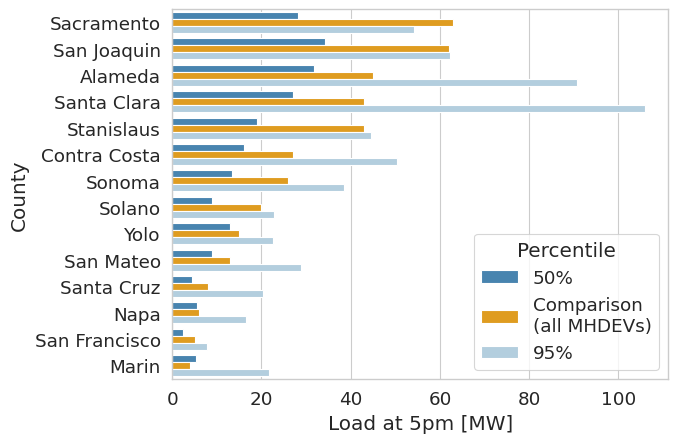

In [12]:
valid_pal = {l: c for c, l in zip(sns.color_palette("Blues_r", n_colors=2), ["50%", "95%"])}
valid_pal.update({"Comparison\n(all MHDEVs)": "orange"})

pal = sns.color_palette("Blues_r", n_colors=3)
ax = sns.barplot(
    data=concat_df,
    x="power_mw",
    y="county_name",
    hue="Percentile",
    palette=valid_pal,
)
ax.set_xlabel("Load at 5pm [MW]");
ax.set_ylabel("County");

catalog.save("validation_comparable_5pm", ax.figure)
ax.figure